<div style="display: flex; align-items: center; padding: 20px; background-color: #f0f2f6; border-radius: 10px; border: 2px solid #007bff;">
    <img src="../logo.png" style="width: 80px; height: auto; margin-right: 20px;">
    <div style="flex: 1; text-align: left;">
    <h1 style="color: #007bff; margin-bottom: 5px;">GLY 6739.017S26: Computational Seismology</h1>
    <h3 style="color: #666;">Notebook 120: Real-time/Raw Seismic Amplitude Measurement (RSAM) - Montserrat example</h3>
    <p style="color: red;"><i>Glenn Thompson | Spring 2026</i></p>
    </div>
</div>

# RSAM notebook

In this tutorial, we will explore Real-time Seismic Amplitude Measurement (RSAM) data. 

RSAM is, by definition, computed on raw seismic data, so we can also think of it as "Raw" Seismic Amplitude Measurement, to distinguish from similar measurements we will make later on velocity and displacement seismograms.

## 1. Original RSAM system

The RSAM system was built around a 8-bit analog-to-digital-converter PC card: software was too slow in those days. Components of the original RSAM system were:

<font color='yellow'>
<ol>
<li>Real-time bar graphs: showing average seismic amplitudes over last 2.56 s, 1 minute, and 10 minutes</li>
<li><b>1 minute and 10 minute mean signal amplitudes, logged to binary files. This is what most volcano-seismologists today think of as "RSAM data"!</b></li>
<li>"RSAM events": created by a simple STA/LTA detector running on each channel (NSLC)</li>
<li>Multi-station event (e.g. earthquake) and tremor alarm systems</li>
<li>Trends in RSAM data and other datasets (e.g. earthquake counts, tiltmeter data, gas flux, deformation, etc.) could be visualized with another software package called "BOB"</li>
</ol></font>

<table border=1><tr><td><img width=100% src="../mess2024/images/rsam.png" ></td><td>RSAM barcharts from Glowworm running in Montserrat in 2002. Tom Murray wrote the original RSAM system in 1985 and the GlowWorm system c. 1998 to provide volcano-monitoring extensions to Earthworm.</td></table></tr></table>

<table border=1><tr><td><img width=100% src="../mess2024/images/EndoMurray1991fig7.png" ></td><td>BOB plot. Fig 7 from Endo & Murray (1991). Top panel shows RSAM event rate at closest station to Pinatubo. Bottom 3 panels show RSAM data from stations at increasing distances. 30 days of data are show</td></table></tr></table>

In the figure above, 30 days of RSAM data are shown for three seismic stations. Loading and plotting 30 days of raw seismic data takes a while, but 1-minute RSAM data downsamples the raw seismic data by a factor of 6,000 (assuming a 100 Hz sampling rate), so long RSAM timeseries (hours, days, weeks, months, etc.) can be quickly loaded and plotted.

Reference:
- Endo, E.T., Murray, T. Real-time Seismic Amplitude Measurement (RSAM): a volcano monitoring and prediction tool. Bull Volcanol 53, 533–545 (1991).__[https://doi.org/10.1007/BF00298154](../../pdf/RSAM_EndoMurray1991.pdf)__

## 2. The RSAM class

We will exploit the RSAM class here (class in the Object-Oriented sense) which is in lib/SAM.py (a "Python module"). One of the methods of the RSAM class is to read the binary files written by the original RSAM system, as we will see.

More importantly, the RSAM class is a convenient way of downsampling (raw) seismic data. The original RSAM system used 2.56s, 60s, and 600s. I prefer to use 2.56s for events, and 60s for continuous data. For each time window, the RSAM class computes the following features:

- mean amplitude
- median amplitude
- max amplitude
- std (same as rms after detrending) amplitude
- mean amplitude in "VT band"
- mean amplitude in "LP band"
- mean amplitude in "VLP band"
- base-2 logarithm of the ratio of VT to LP band amplitudes (frequency ratio ...)

These are all features can be quickly computed because they can be done in the time domain. 

We can process the data in various ways. Some of these, e.g. using `select()`, `trim()`, `plot()`, should be familiar from ObsPy `Stream` objects. Others such as `downsample()` are not.

## 3. Frequency ratio
One of the metrics computed by the RSAM class is the "Frequency Ratio", which is a base-2 logarithm of the amplitude ratio of the VT frequency band versus the LP frequency band:

\begin{align}
fratio & = log_{2} \frac {A_{VT}}{A_{LP}} \\
\end{align}

                                                                        (Rodgers et al., 2016)

We use the following definitions of the VT and LP bands:

<table border=1>
    <tr><td>Class</td><td>Frequency Band (Hz)</td></tr>
    <tr><td>LP</td><td>0.8 - 4.0</td></tr>
    <tr><td>VT</td><td>4.0 - 18.0</td></tr>
</table>


## 4. Setup the SDS archive we will use

To have access to the data on the server, first we run this:

In [1]:
import sys
sys.path.append('../week8') # this is where set_samba_data_root.py lives
from set_samba_data_root import DATA_ROOT # this sets DATA_ROOT to the path of the samba share on your system

Check what is in the DATA_ROOT directory:

In [2]:
from flovopy.utils.misc import tree
print(f"DATA_ROOT is set to: {DATA_ROOT}")
tree(DATA_ROOT, max_depth=0, dirs_only=True)

DATA_ROOT is set to: /Volumes/classdata
├── css3
├── kmz_work
├── KSC
├── KSC_2026
├── Montserrat
├── NevadoDelRuiz
├── Pinatubo
├── remastered
├── rover_data_repo
├── SAM
├── SDS_Alaska
├── SDS_MVO
├── SDS_Sakurajima
└── SEISAN_DB


Now set path to SDS_MVO directory, and see what files are available:

In [3]:
from pathlib import Path
#SDS_MVO_ROOT = DATA_ROOT / "SDS_MVO"
SDS_MVO_ROOT = Path('~').expanduser() / 'work' / 'SDS'
tree(SDS_MVO_ROOT)

├── 2003
│   ├── MV
│   │   ├── MBGB
│   │   │   └── BHZ.D
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.182
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.183
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.184
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.185
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.186
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.187
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.188
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.189
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.190
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.191
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.192
│   │   │       ├── MV.MBGB.--.BHZ.D.2003.193
│   │   │       └── MV.MBGB.--.BHZ.D.2003.194
│   │   ├── MBGH
│   │   │   └── BHZ.D
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.182
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.183
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.184
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.185
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.186
│   │   │       ├── MV.MBGH.--.BHZ.D.2003.187
│   │   │       ├── MV.MBGH.

Now check data availability. We can do this with:
```EnhancedSDSClient.get_availability()```


In [4]:
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy.core import UTCDateTime
startTime = UTCDateTime(2003, 7, 1)   # start date (inclusive)
endTime   = UTCDateTime(2003, 7, 14)  # end date (exclusive)

# -----------------------------------------------------------------------------
# Initialize SDS client (points to your SDS archive on disk)
# -----------------------------------------------------------------------------
mySDSclient = EnhancedSDSClient(SDS_MVO_ROOT)

#availdf, ids = mySDSclient.get_availability(startday=startTime, endday=endTime, verbose=True)
#display(availdf)

## 5. Compute RSAM (simple example)

Here is a minimal example of computing RSAM data. First we read data from a Seisan archive. The data come from Montserrat on 12th July 2003. 

### 5.1 Read data from SDS archive

We are still using the EnhancedSDSClient from above, but now we are only getting 1 day of data

In [5]:
t0 = UTCDateTime(2003,7,12)
st = mySDSclient.get_waveforms(
    network="MV",
    station="*",
    location="*",
    channel="*Z",
    starttime=t0,
    endtime=t0 + 24*3600, # get one day of data
)

print(st)

8 Trace(s) in Stream:
MV.MBGB..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBGH..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBLG..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBLY..HHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 100.0 Hz, 8640001 samples
MV.MBRV..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBRY..BHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBSS..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples
MV.MBWH..SHZ | 2003-07-12T00:00:00.000000Z - 2003-07-13T00:00:00.000000Z | 75.0 Hz, 6480001 samples


### 5.2 Plot Stream

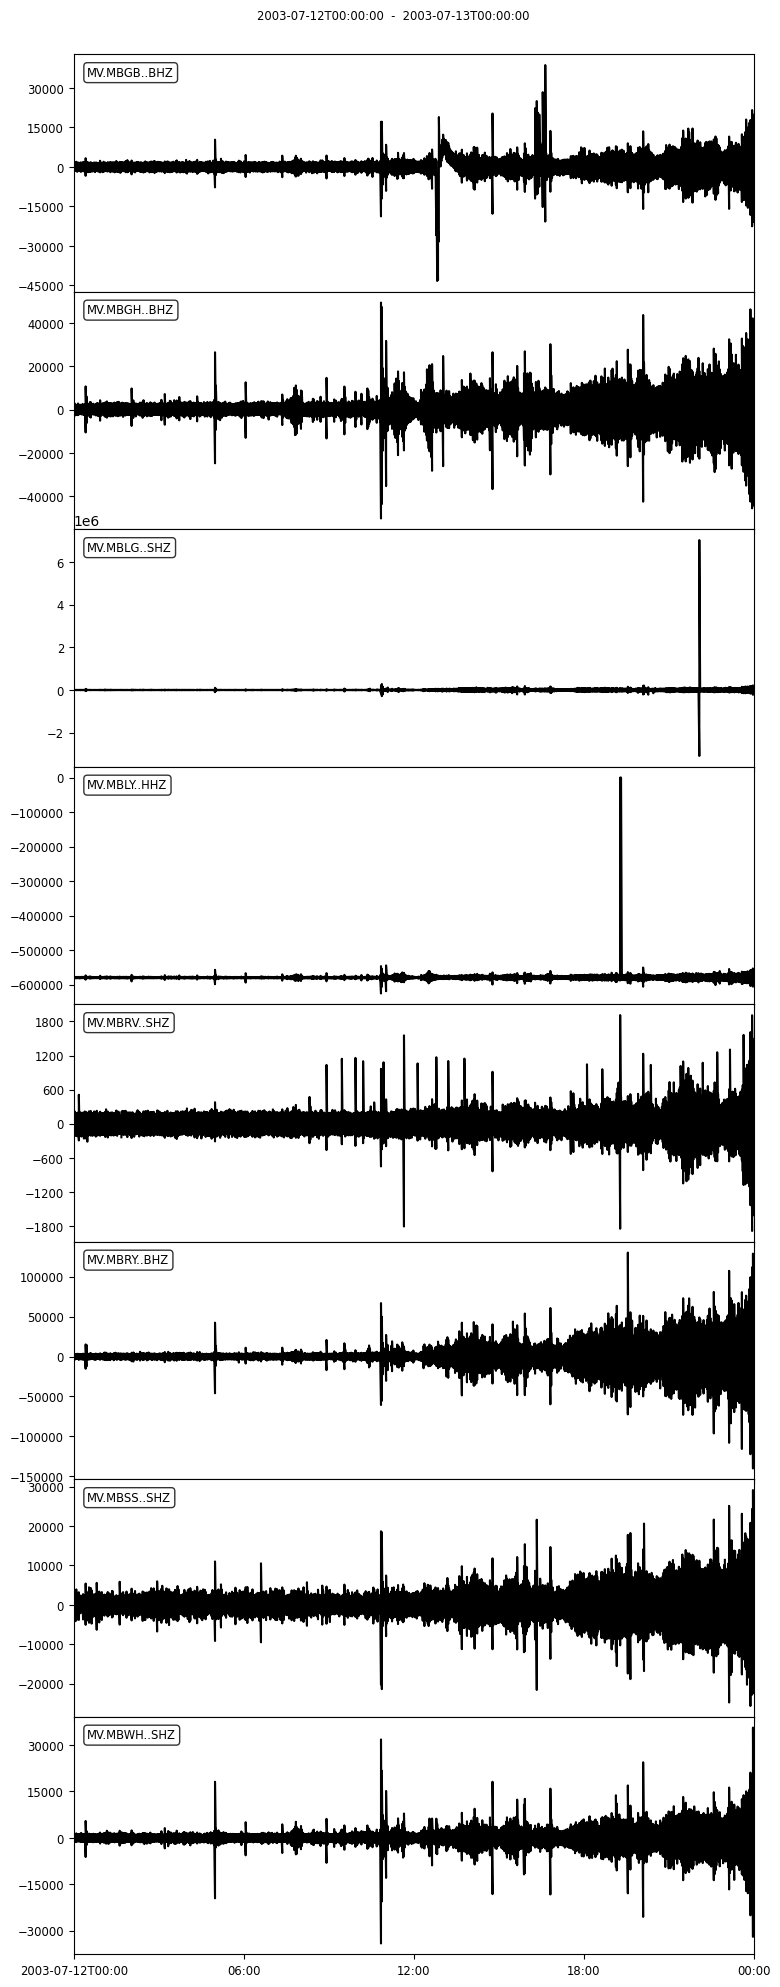

In [6]:
st.plot(equal_scale=False);

### 5.3 Compute & Plot 1-minute RSAM data

An RSAM object is created from an ObsPy Stream and computes time-averaged seismic amplitudes over a fixed interval (typically 1 minute).

⸻

#### Basic usage

```python
rsamObj = RSAM(stream=st, sampling_interval=60)
```

This computes RSAM values every 60 seconds using default preprocessing and filtering.

⸻

What happens under the hood
The call above is equivalent to:

```python
rsamObj = RSAM(
    stream=st,
    sampling_interval=60.0,
    filter=[0.5, 18.0],
    bands={
        'VLP': [0.02, 0.2],
        'LP':  [0.5, 4.0],
        'VT':  [4.0, 18.0],
    },
    corners=4,
    despike=False,
    verbose=False,
)
```

⸻

#### Key parameters

- **`sampling_interval`**  
  Duration (in seconds) over which amplitudes are averaged.  
  Can range from 1 second to 86400 seconds (1 day).  
  Default: **60 seconds**

- **`filter`**  
  A bandpass filter applied before RSAM calculation.  
  Default: **[0.5, 18.0] Hz**, which captures most volcano-seismic energy.

- **`bands`**  
  Defines named frequency bands for multi-band RSAM analysis:
  - **VLP (Very Long Period):** 0.02–0.2 Hz  
  - **LP (Long Period):** 0.5–4.0 Hz  
  - **VT (Volcano-Tectonic):** 4.0–18.0 Hz  

  A frequency ratio (**VT / LP**) is also computed to help distinguish:
  - VT-dominated seismicity (fracturing)
  - LP-dominated signals (fluid/magma movement)

  If your dataset has different spectral characteristics, you should adjust these bands accordingly.

- **`corners`**  
  Number of filter corners (controls filter steepness).  
  Default: **4**

- **`despike`**  
  Removes impulsive spikes before averaging.  
  Disabled by default.

---

#### When should you change defaults?

You should override parameters when:

- Working with **non-volcanic data** → adjust `filter` and `bands`  
- Using **different sampling rates** → adjust filter limits  
- Studying **specific processes** (e.g., tremor vs explosions)  
- Computing **custom ratios** → redefine `bands`  

⸻

#### Example: Custom band definitions

```python
rsamObj = RSAM(
    stream=st,
    sampling_interval=60,
    bands={
        'LP': [0.5, 2.0],
        'VT': [2.0, 10.0],
    }
)
```

OK, let's compute RSAM on the Stream object st:

In [7]:
from flovopy.processing.sam import RSAM
rsamObj = RSAM(stream=st, sampling_interval=60) # 60-s sampling interval
print(rsamObj)

RSAM object:
Number of SEED ids: 8 [['MV.MBGB..BHZ', 'MV.MBGH..BHZ', 'MV.MBLG..SHZ', 'MV.MBLY..HHZ', 'MV.MBRV..SHZ', 'MV.MBRY..BHZ', 'MV.MBSS..SHZ', 'MV.MBWH..SHZ']]
Number of rows: 1440
Start time: 2003-07-12T00:00:00.000000Z
End time: 2003-07-13T00:00:00.000000Z
Duration: 86400.0 s
Sampling interval: 60.0 s
Metrics: min, mean, max, median, rms, VLP, LP, VT, fratio
MV.MBGB..BHZ: median=383
MV.MBGH..BHZ: median=1.11e+03
MV.MBLG..SHZ: median=5.69e+03
MV.MBLY..HHZ: median=694
MV.MBRV..SHZ: median=38.6
MV.MBRY..BHZ: median=1.55e+03
MV.MBSS..SHZ: median=522
MV.MBWH..SHZ: median=391


METRIC: mean
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Regularizing dataframe with 1439 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


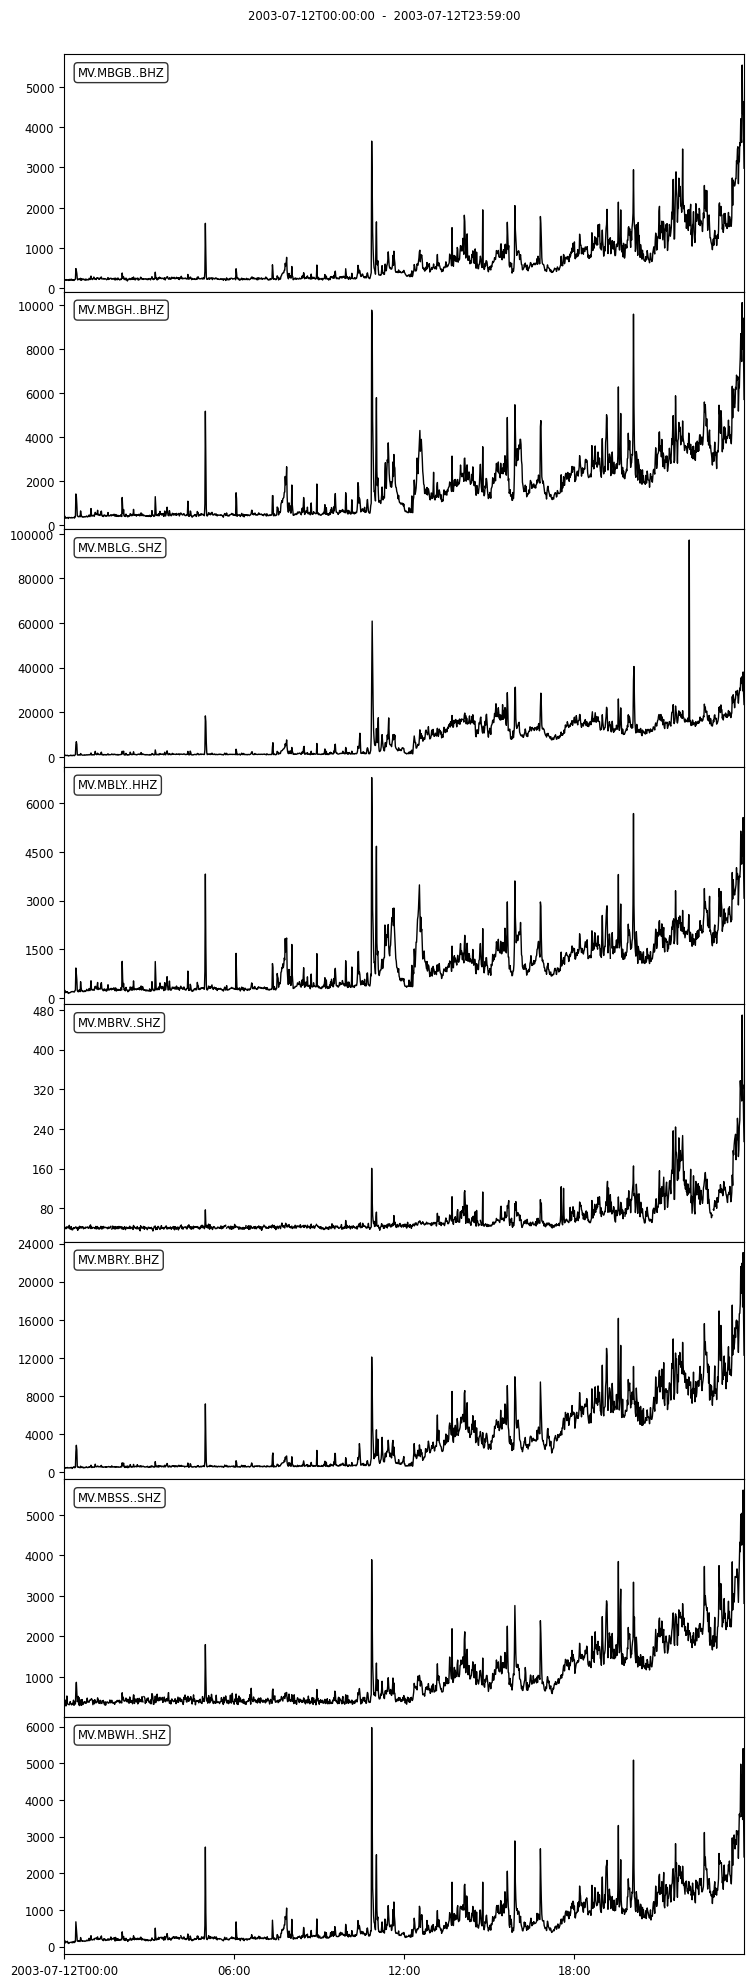

In [8]:
rsamObj.plot()

### 5.4 Contents of an RSAM object

Internally, RSAM data for each ObsPy Trace object in the Stream is held in a pandas DataFrame. 

In the present example, the Stream only contains 1 Trace and we can view the dataframe with:

In [9]:
print(f'SEED ids in RSAM object: {rsamObj.seed_ids}')
display(rsamObj.dataframes['MV.MBWH..SHZ'])

SEED ids in RSAM object: ['MV.MBGB..BHZ', 'MV.MBGH..BHZ', 'MV.MBLG..SHZ', 'MV.MBLY..HHZ', 'MV.MBRV..SHZ', 'MV.MBRY..BHZ', 'MV.MBSS..SHZ', 'MV.MBWH..SHZ']


,time,min,mean,max,median,rms,VLP,LP,VT,fratio
0,1.057968e+09,0.000378,131.656490,853.879063,88.596059,134.757738,4.084763,116.307792,55.531537,-1.066569
1,1.057968e+09,0.053804,166.658230,1062.516018,112.080548,165.849837,5.079374,144.780785,71.395661,-1.019962
2,1.057968e+09,0.007062,155.306115,1027.020744,101.025359,160.783249,5.750944,138.683072,64.049261,-1.114538
3,1.057968e+09,0.030044,101.869917,791.730041,68.345279,114.144282,5.891535,85.100705,51.018781,-0.738143
4,1.057968e+09,0.000675,120.210411,1030.803109,70.996790,149.594162,4.780025,102.980426,55.452557,-0.893044
...,...,...,...,...,...,...,...,...,...,...
1435,1.058054e+09,0.012059,4680.487364,20467.834592,3883.000779,3589.222743,6.697247,4552.929704,1126.810890,-2.014550
1436,1.058054e+09,2.093220,3468.717215,14036.625459,2956.473509,2594.504327,5.012833,3312.540082,1043.523704,-1.666475
1437,1.058054e+09,1.032083,5403.785189,28571.608325,4342.451232,4560.622516,4.976709,5164.921943,1562.700304,-1.724705
1438,1.058054e+09,0.273505,3527.799249,16511.685747,2821.918441,2821.803909,6.105063,3350.037513,1029.157119,-1.702714


The 'time' column is in Unix epoch seconds (since 1970-01-01 00:00:00) 

### 5.5 Subsetting an RSAM object: select & trim

```RSAM.trim()```

RSAM objects can be select in the same way as Stream objects:



In [10]:
rsamObj2 = rsamObj.select(id='MV.MBWH..SHZ')
print(rsamObj2)

RSAM object:
Number of SEED ids: 1 [['MV.MBWH..SHZ']]
Number of rows: 1440
Start time: 2003-07-12T00:00:00.000000Z
End time: 2003-07-13T00:00:00.000000Z
Duration: 86400.0 s
Sampling interval: 60.0 s
Metrics: min, mean, max, median, rms, VLP, LP, VT, fratio
MV.MBWH..SHZ: median=391


```RSAM.trim()```

RSAM objects can also also be trimmed in the same way as Stream objects:

In [11]:
rsamObj3 = rsamObj.copy() # make a copy of the original RSAM object so that we can modify it without affecting the original
rsamObj3.trim(starttime=t0+3600, endtime=t0+7200) # trim happens in-place, so rsamObj3 is modified
print(rsamObj3)

RSAM object:
Number of SEED ids: 8 [['MV.MBGB..BHZ', 'MV.MBGH..BHZ', 'MV.MBLG..SHZ', 'MV.MBLY..HHZ', 'MV.MBRV..SHZ', 'MV.MBRY..BHZ', 'MV.MBSS..SHZ', 'MV.MBWH..SHZ']]
Number of rows: 61
Start time: 2003-07-12T01:00:00.000000Z
End time: 2003-07-12T02:01:00.000000Z
Duration: 3660.0 s
Sampling interval: 60.0 s
Metrics: min, mean, max, median, rms, VLP, LP, VT, fratio
MV.MBGB..BHZ: median=202
MV.MBGH..BHZ: median=355
MV.MBLG..SHZ: median=816
MV.MBLY..HHZ: median=200
MV.MBRV..SHZ: median=34.2
MV.MBRY..BHZ: median=456
MV.MBSS..SHZ: median=304
MV.MBWH..SHZ: median=138


### 5.6 Plotting different metrics (dataframe columns)

The original RSAM system calculated the mean signal amplitude at sample intervals of 2.56s, 60s, and 600s, as shown in the bar graph above. However, it is cheap and fast today to compute and store other metrics for each sample interval too, so RSAM objects also contain the min, max, median, and rms amplitude of each sample interval. (The aforementioned VLP, LP, and VT bands are computed just with the mean). A full list of the available metrics can be gotten like this:

In [12]:
print(rsamObj2.metrics)

['min', 'mean', 'max', 'median', 'rms', 'VLP', 'LP', 'VT', 'fratio']


Specific metrics can be plotted - just set metrics to a list:

METRIC: mean
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


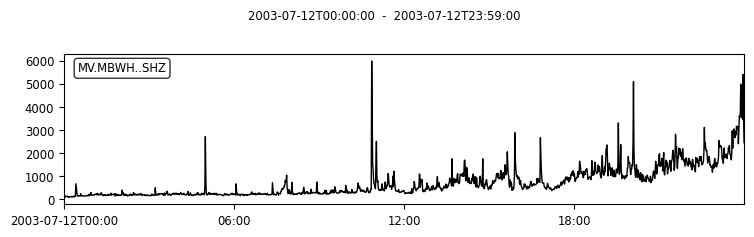

METRIC: median
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


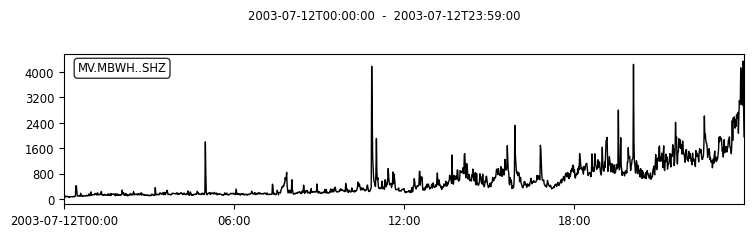

METRIC: rms
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


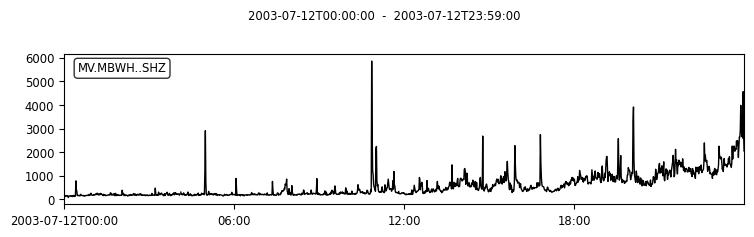

METRIC: max
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


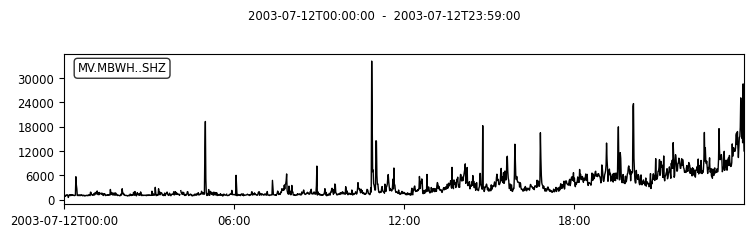

METRIC: LP
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


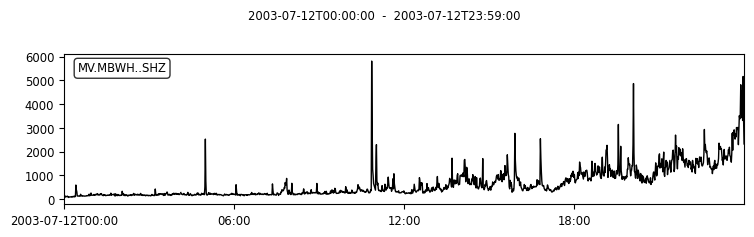

METRIC: VT
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


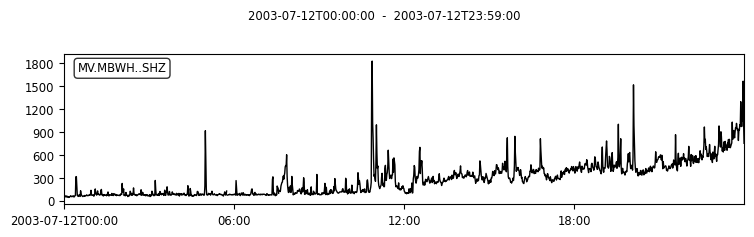

METRIC: fratio
Regularizing dataframe with 1440 rows onto a 60 s grid based on column 'time'


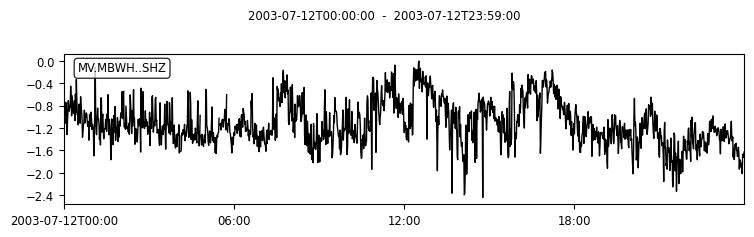

In [13]:
rsamObj2.plot(metrics=['mean','median','rms', 'max', 'LP', 'VT', 'fratio'])

For tremor analysis, I prefer to use the median, because it isn't biased by outliers the way the mean, rms, and max are. On the other hand, if my focus is to see the size of the largest events, it might be best to plot the max.

## 6. Computing RSAM for multiple days
Loading more than 1 day of data into a Stream object is generally not a good idea if the data are sampled at 100 Hz, or more. So a better strategy is to load data 1 day, or maybe even 1 hour, at a time.

Here is an example of how we can compute RSAM for 1 SEED id for multiple days.

### 6.1 Loop over days, loading from SDS, computing RSAM, and saving to file

In [14]:
import os
from obspy.core import UTCDateTime
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from flovopy.processing.sam import RSAM

# -----------------------------------------------------------------------------
# Output directory for RSAM (SAM) data
# -----------------------------------------------------------------------------
# Expand "~" to your home directory and create the folder if it doesn't exist
SAM_DIR = os.path.expanduser('~/work/CompSci26/week10/sam_data')
os.makedirs(SAM_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# Initialize SDS client (points to your SDS archive on disk)
# -----------------------------------------------------------------------------
mySDSclient = EnhancedSDSClient(SDS_MVO_ROOT)

# -----------------------------------------------------------------------------
# Define time range for processing
# -----------------------------------------------------------------------------
startTime = UTCDateTime(2003, 7, 1)   # start date (inclusive)
endTime   = UTCDateTime(2003, 7, 14)  # end date (exclusive)

# Number of seconds in one day (used for stepping through time)
secondsPerDay = 60 * 60 * 24

# Total number of days (not strictly needed, but useful for reference/debugging)
numDays = (endTime - startTime) / secondsPerDay

# Initialize loop variable
daytime = startTime

# -----------------------------------------------------------------------------
# Loop over each day and compute RSAM
# -----------------------------------------------------------------------------
while daytime < endTime:

    # -------------------------------------------------------------------------
    # Step 1: Load waveform data from SDS archive for one day
    # -------------------------------------------------------------------------
    print(f'Loading Stream data for {daytime}')

    st = mySDSclient.get_waveforms(
        "MV",     # network code
        "*",   # station code
        "*",       # location code (empty = any)
        "*Z",    # channel (vertical short-period)
        daytime,
        daytime + secondsPerDay
    )

    print(f'- got {len(st)} Trace ids')

    # -------------------------------------------------------------------------
    # Step 2: Compute RSAM metrics
    # -------------------------------------------------------------------------
    # RSAM = Real-time Seismic Amplitude Measurement
    # Here computed at 60-second intervals (1-minute RSAM)
    print(f'Computing RSAM metrics for {daytime}, and saving to pickle files')

    rsamMV24h = RSAM(
        stream=st,
        sampling_interval=60  # 1-minute RSAM
    )

    # -------------------------------------------------------------------------
    # Step 3: Save RSAM results to disk
    # -------------------------------------------------------------------------
    # Writes one file per station/channel/day
    rsamMV24h.write(
        str(SAM_DIR),
        ext='csv',        # output format (csv files)
        overwrite=False    # overwrite existing files if present
    )

    # -------------------------------------------------------------------------
    # Step forward one day
    # -------------------------------------------------------------------------
    daytime += secondsPerDay

Loading Stream data for 2003-07-01T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-01T00:00:00.000000Z, and saving to pickle files


/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:282: RuntimeWarning: All-NaN slice encountered
  df['min']    = pd.Series(np.nanmin(Y, axis=1))
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:283: RuntimeWarning: Mean of empty slice
  df['mean']   = pd.Series(np.nanmean(Y, axis=1))
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:284: RuntimeWarning: All-NaN slice encountered
  df['max']    = pd.Series(np.nanmax(Y, axis=1))
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:308: RuntimeWar

Loading Stream data for 2003-07-02T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-02T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-03T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-03T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-04T00:00:00.000000Z
- got 9 Trace ids
Computing RSAM metrics for 2003-07-04T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-05T00:00:00.000000Z
- got 7 Trace ids
Computing RSAM metrics for 2003-07-05T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-06T00:00:00.000000Z
- got 7 Trace ids
Computing RSAM metrics for 2003-07-06T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-07T00:00:00.000000Z
- got 7 Trace ids
Computing RSAM metrics for 2003-07-07T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-08T00:00:00.000000Z
- got 7 Trace ids
Computing RS

/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:282: RuntimeWarning: All-NaN slice encountered
  df['min']    = pd.Series(np.nanmin(Y, axis=1))
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:283: RuntimeWarning: Mean of empty slice
  df['mean']   = pd.Series(np.nanmean(Y, axis=1))
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:284: RuntimeWarning: All-NaN slice encountered
  df['max']    = pd.Series(np.nanmax(Y, axis=1))
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/processing/sam.py:308: RuntimeWar

Loading Stream data for 2003-07-11T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-11T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-12T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-12T00:00:00.000000Z, and saving to pickle files
Loading Stream data for 2003-07-13T00:00:00.000000Z
- got 8 Trace ids
Computing RSAM metrics for 2003-07-13T00:00:00.000000Z, and saving to pickle files


### 6.2 Read back all the RSAM data & plot
We wrote RSAM data one day at a time so as not to overload memory with giant Stream objects. But now we can easily load back the full RSAM timeseries, since it is downsampled by 60 * 75 = 4500 times.

Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 17403 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 18560 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 80 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 9160 rows onto a 60 s grid based on column 'time'
METRIC: median
Dataframe with 18720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 18720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 18720 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 18720 rows is 

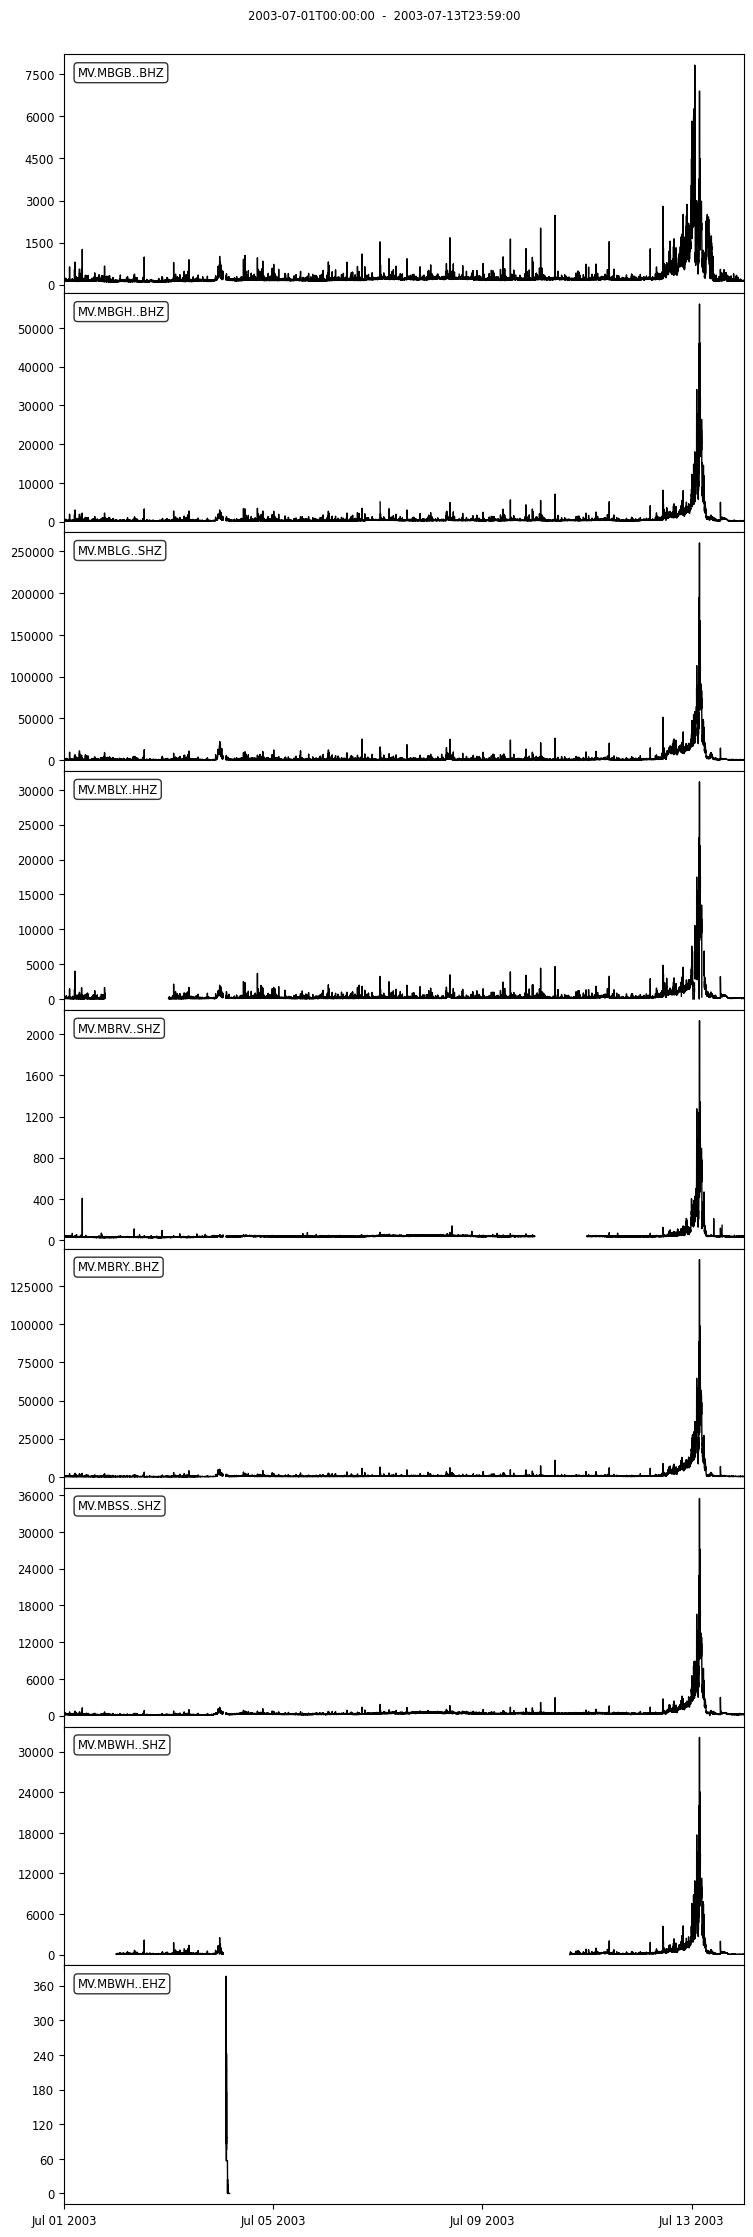

In [15]:
# Read all the RSAM data back, and plot
rsamObj4 = RSAM.read(startTime, endTime, SAM_DIR=str(SAM_DIR), ext='csv')
rsamObj4.plot(metrics='median')

### 6.3 Frequency ratio
Let's plot the frequency ratio (or "band ratio") for station MBSS:

METRIC: fratio
Dataframe with 18720 rows is already on a regular 60 s grid based on column 'time'


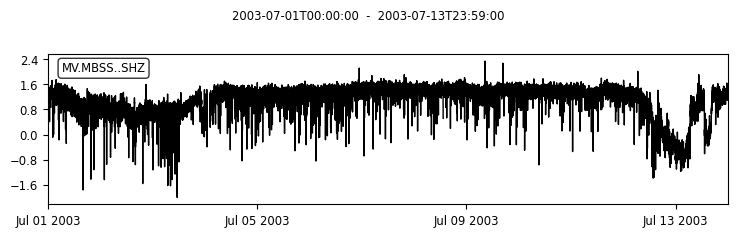

In [16]:
rsamObj4.select(station='MBSS').plot(metrics=['fratio'])

As you can see, there is a considerable 6-hour decline in frequency ratio prior from late on 2003/07/12. Similar downshifts in frequency ratio have been used to 'postdict' eruptions, e.g. Whakaari/White Island on 2019/12/09.

### 6.4 Peak RSAM

Finally, when does the peak RSAM occur? This might be the time of the explosive blast that followed hours of dome collapse activity. ]

In [17]:
# All stations
peak_df = rsamObj4.get_peak_dataframe(metric="median")
display(peak_df)

,peak_time_epoch,peak_time,peak_amplitude,metric,n_rows,seed_id
0,1.057285e+09,2003-07-04 02:23:00+00:00,376.455001,median,100,MV.MBWH..EHZ
1,1.058060e+09,2003-07-13 01:25:00+00:00,7834.078293,median,18720,MV.MBGB..BHZ
2,1.058067e+09,2003-07-13 03:34:00+00:00,259977.308022,median,18720,MV.MBLG..SHZ
3,1.058067e+09,2003-07-13 03:34:00+00:00,31167.101646,median,18720,MV.MBLY..HHZ
4,1.058067e+09,2003-07-13 03:34:00+00:00,142419.459739,median,18720,MV.MBRY..BHZ
5,1.058067e+09,2003-07-13 03:34:00+00:00,35467.620173,median,18720,MV.MBSS..SHZ
6,1.058067e+09,2003-07-13 03:34:00+00:00,32126.112100,median,18720,MV.MBWH..SHZ
7,1.058067e+09,2003-07-13 03:35:00+00:00,56140.915883,median,18720,MV.MBGH..BHZ
8,1.058067e+09,2003-07-13 03:35:00+00:00,2132.242639,median,18720,MV.MBRV..SHZ


## 7. Legacy RSAM data 

### 7.1 Loading legacy RSAM data from binary files

The RSAM system was used at many observatories, and so many observatories likely have archives of RSAM binary files. But we can read these, making them Interoperable and Reusable. (Tiltmeter was saved in the same format, and so can also be read).

Next we will load 1 year of RSAM data for 8 stations recorded by the original RSAM system that was deployed in Montserrat. These data only have a 'mean' metric - it is just how they were recorded at the time.


In [18]:
from obspy.core import UTCDateTime
stime = UTCDateTime(1996,1,1)
etime = UTCDateTime(1997,1,1)-1
BINARY_DIR = DATA_ROOT / 'Montserrat' / "ASN" / "RSAM" / "RSAM_1"
print(BINARY_DIR)
files = list(BINARY_DIR.glob(f'M???{stime.year}.DAT'))
stations = [path.name[0:4] for path in files]
legacyObj = RSAM.readRSAMbinary(str(BINARY_DIR), stations, stime, etime, convert_legacy_ids_using_this_network="MV")

/Volumes/classdata/Montserrat/ASN/RSAM/RSAM_1
Regularizing dataframe with 115317 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 499411 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 105343 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 521715 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 225139 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 521715 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 478516 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 345732 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 345734 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 261354 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 27399 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 27399 rows onto a 60 s grid based on column 'ti

### 7.2 Converting legacy RSAM binary files to modern RSAM CSV/Pickle files
Since we have already read the binary files into a (single) RSAM object, writing them to modern RSAM data format is as simple as:

In [19]:
legacyObj.write(str(SAM_DIR), ext='csv')

### 7.3 read and plot
Next we will:
- (re-)read (from disk) the RSAM data from 1996/08/02 to 1996/08/06 from the newly converted RSAM files (CSV rather than binary files)
- plot the data. By default, the plot() method will convert RSAM dataframes into an ObsPy Stream object, so it can be plotted in a familiar way.

Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 5684 rows onto a 60 s grid based on column 'time'
METRIC: mean
Dataframe with 5760 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 5760 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 5760 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 5760 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 5760 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 5760 rows is alr

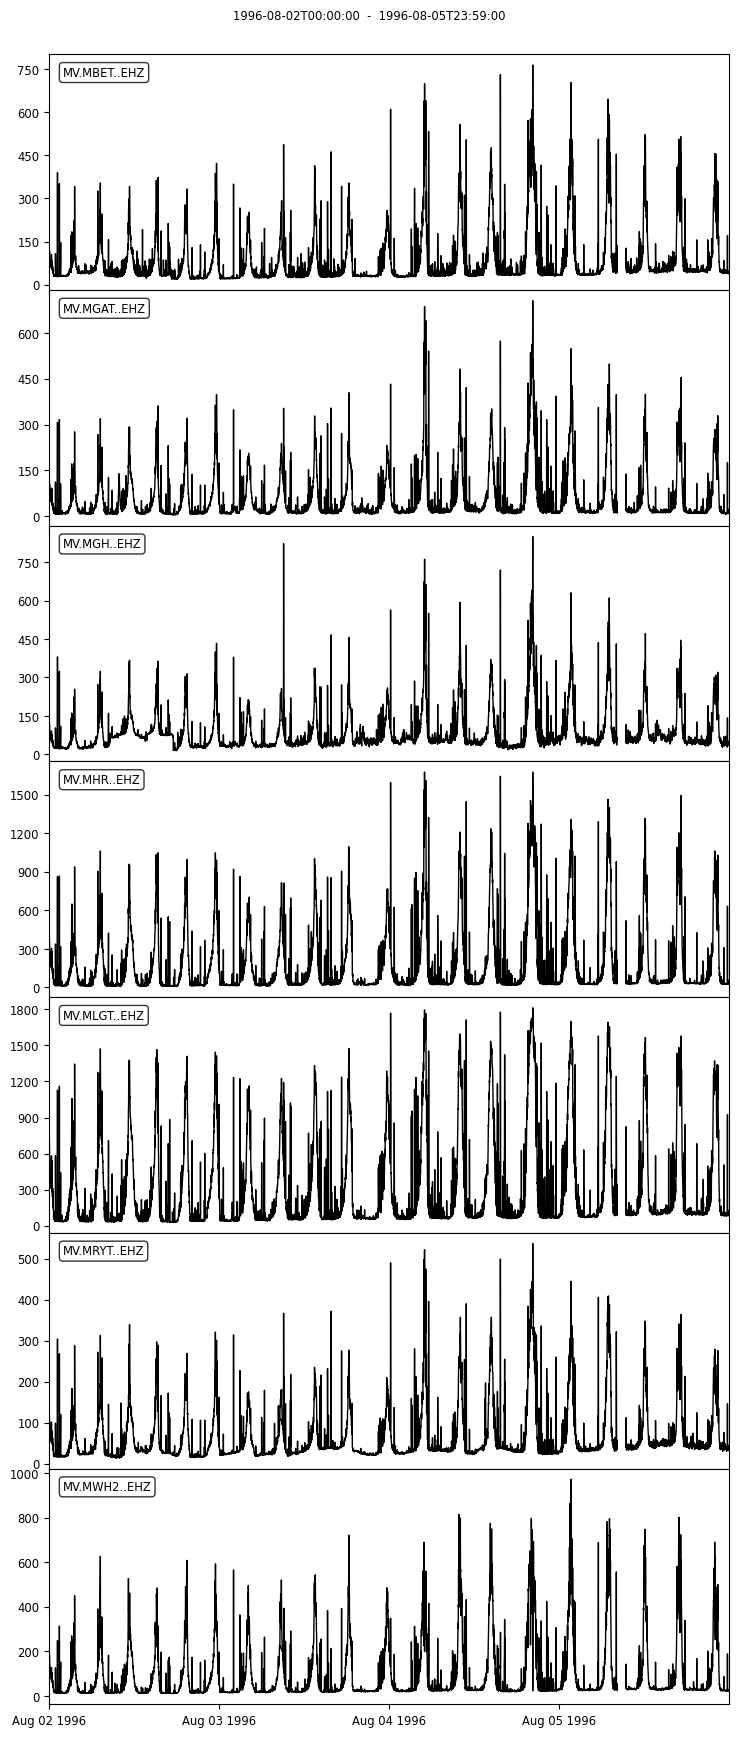

In [20]:
stations = ['MBET', 'MGAT', 'MGH', 'MHR', 'MLGT', 'MRYT', 'MWH2']
trace_ids = [f'MV.{sta}..EHZ' for sta in stations]
startt = UTCDateTime(1996,8,2)
endt = UTCDateTime(1996,8,6)
rsamObj = RSAM.read(startt, endt, SAM_DIR=str(SAM_DIR), ext='csv', trace_ids=trace_ids)
rsamObj.plot()   

### 7.4 Downsample 

RSAM data can be easily downsampled, so it is generally best to compute RSAM at the highest time resolution you expect to need, and reduce the sampling later as required.

However, the choice of time interval should be consistent with the frequency band of interest. For the default bands:

- **LP (0.5–4.0 Hz):** use sampling intervals no shorter than ~2.5 seconds  
- **VLP (0.02–0.2 Hz):** use sampling intervals no shorter than ~60 seconds  

In practice, a **60-second interval** is a sensible default that works well across most applications.

For visualization, further downsampling is often helpful to reduce noise and highlight trends:

- **> 24 hours:** ~10-minute averages  
- **> 1 week:** ~1-hour averages  
- **> 1 year:** ~1-day averages  

These longer intervals improve readability and make long-term patterns easier to interpret.

METRIC: mean
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'


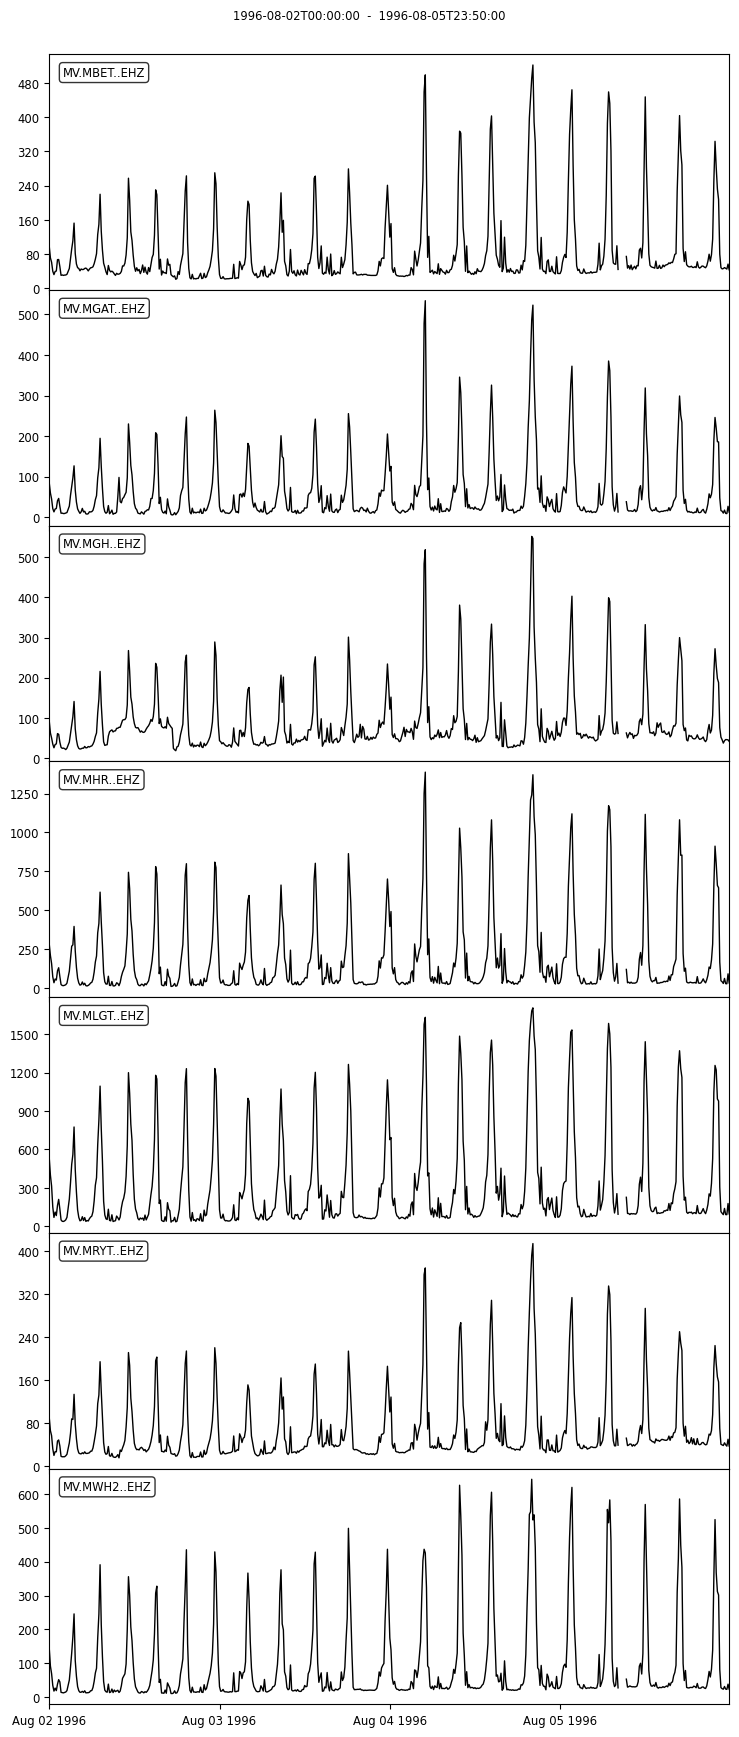

In [21]:
# downsample
rsamObj2 = rsamObj.downsample(new_sampling_interval=600) 

# plot
rsamObj2.plot()

These are remarkable cycles in RSAM. They appear to be about 4-6 hours apart. This is a phenomenon called "banded tremor". During these tremor bands, visual observations indicated that the lava dome was extruding at particularly high rates (up to 20m^3 was one estimate I heard), and at the peak of each cycle there was often ash venting. I proposed that the tremor bands were indicated of pressure cycles within the conduit - but caused by what? 
One suggestion is that the magma rises up the conduit in a stick-slip fashion. Basically, it gets stuck for a while, as the pressure builds below, and then shear fractures, allowing magma to suddenly extrude very quickly. 

### 7.5 Tremor band detection with ObsPy trigger methods

Can we use some ObsPy STA/LTA detection tools to detect these tremor bands, in the same way we normally detect much shorter transient events, but just with longer STA/LTA settings? Let us try first on a single NSLC. This is based on examples at https://docs.obspy.org/tutorial/code_snippets/trigger_tutorial.html, except we use longer STA and LTA time windows (15 and 100 minutes respectively), and we add a despiking step which attempts to remove transient events lasting a minute or less from the data before running the STA/LTA:

#### Setup parameters

In [22]:
from obspy.signal.trigger import plot_trigger, classic_sta_lta, recursive_sta_lta

st2 = rsamObj2.select(component='Z').to_stream()

sta_minutes = 15
lta_minutes = 100
threshON = 0.8
threshOFF = 0.5

Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'
Regularizing dataframe with 570 rows onto a 600 s grid based on column 'time'


#### 7.5.1 Single-channel (one Trace at a time) tremor band detection
This is like most of the ObsPy examples in https://docs.obspy.org/tutorial/code_snippets/trigger_tutorial.html - an STA/LTA detection algorithm is applied to each Trace object separately. There is no association of detections across the whole Stream object into events.

MV.MBET..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


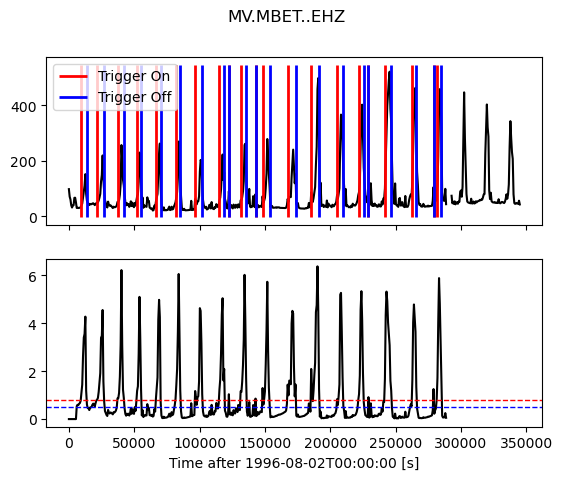

MV.MGAT..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


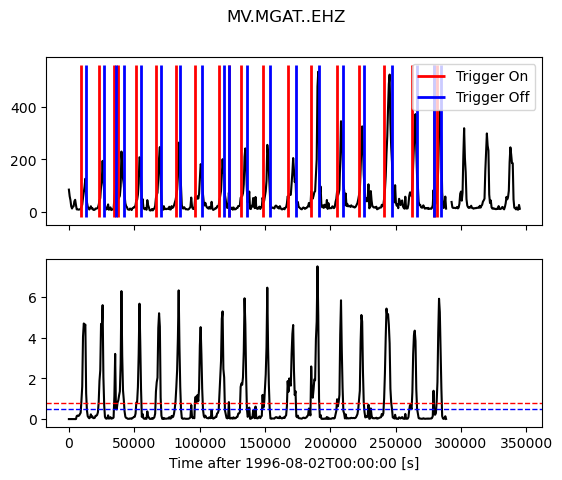

MV.MGH..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


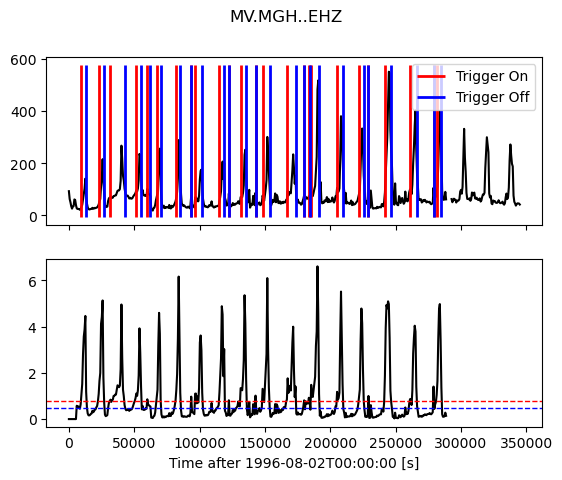

MV.MHR..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


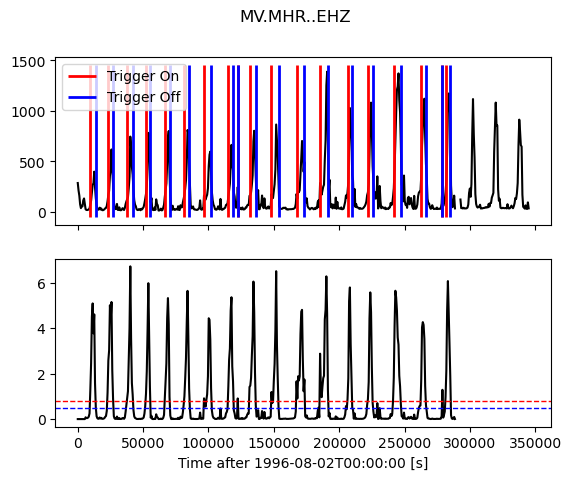

MV.MLGT..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


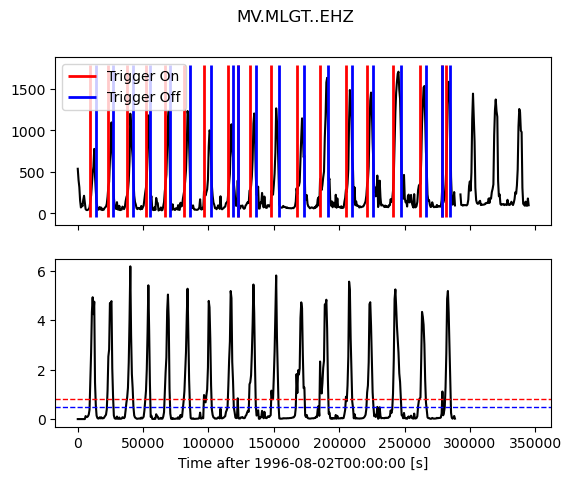

MV.MRYT..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


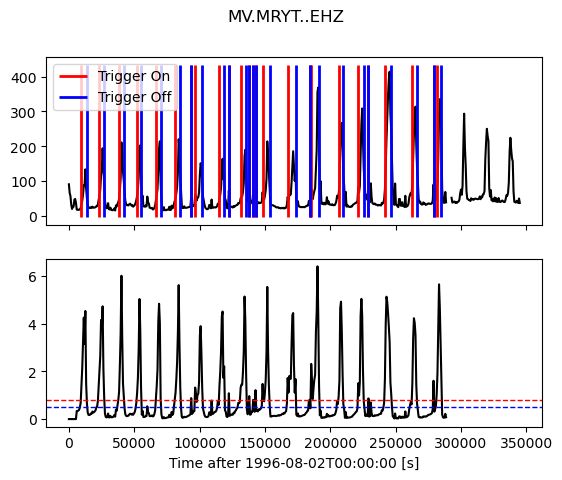

MV.MWH2..EHZ | 1996-08-02T00:00:00.000000Z - 1996-08-05T23:50:00.000000Z | 600.0 s, 576 samples (masked)


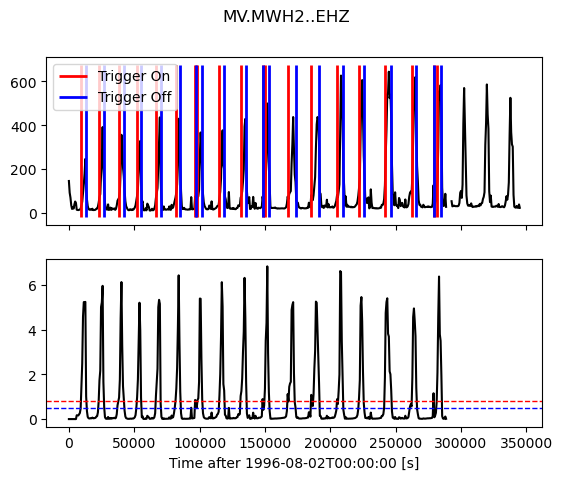

In [23]:
for tr in st2:
    print(tr)
    sampling_interval_minutes = tr.stats.delta/60
    cft = recursive_sta_lta(tr.data, int(sta_minutes / sampling_interval_minutes), int(lta_minutes / sampling_interval_minutes))

    plot_trigger(tr, cft, threshON, threshOFF)

#### 7.5.2 Multi-Channel (one Stream at a time) tremor band detection
The ObsPy coincidence_trigger() function performs detection and association across the whole Stream in one step. The event_triggering.py module we used in week8 wraps coincidence_trigger() to make it easier to use and to assemble the output into a dataframe of events, each with an on and off time. I've moved the functionality from that module into flovopy.processing.detection:

,event_index,on_time,off_time,duration_s,seed_ids,n_seed_ids,pretrigger_s,posttrigger_s,outdir,filename,...,wrote_file,coincidence_sum,signal_rms,noise_rms,snr_rms,stations,trace_ids,cft_peaks,cft_peak_wmean,cluster_size
0,0,1996-08-02 02:40:00,1996-08-02 03:50:00,4200.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T024000.mseed,...,False,7.0,88.122918,35.6,2.475363,"[MGAT, MGH, MWH2, MBET, MHR, MLGT, MRYT]","[MV.MGAT..EHZ, MV.MGH..EHZ, MV.MWH2..EHZ, MV.M...","[4.704423240195984, 4.460879100736874, 5.24790...",4.746537,None
1,1,1996-08-02 06:00:00,1996-08-02 07:30:00,5400.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T060000.mseed,...,False,7.0,114.653269,30.7,3.734634,"[MBET, MGAT, MGH, MHR, MLGT, MRYT, MWH2]","[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...","[4.550511975120101, 5.60448091976672, 5.131295...",5.127497,None
2,2,1996-08-02 08:50:00,1996-08-02 11:50:00,10800.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T085000.mseed,...,False,7.0,120.105995,40.0,3.002650,"[MGH, MGAT, MBET, MHR, MLGT, MRYT, MWH2]","[MV.MGH..EHZ, MV.MGAT..EHZ, MV.MBET..EHZ, MV.M...","[4.95595084161464, 3.206659308954583, 6.214866...",5.629114,None
3,3,1996-08-02 14:10:00,1996-08-02 15:20:00,4200.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T141000.mseed,...,False,7.0,153.008823,38.9,3.933389,"[MGH, MGAT, MBET, MHR, MLGT, MRYT, MWH2]","[MV.MGH..EHZ, MV.MGAT..EHZ, MV.MBET..EHZ, MV.M...","[3.924188800903183, 5.676221199011478, 5.09785...",5.188490,None
4,4,1996-08-02 18:30:00,1996-08-02 19:30:00,3600.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T183000.mseed,...,False,7.0,158.984797,58.3,2.727012,"[MBET, MGAT, MHR, MLGT, MRYT, MWH2, MGH]","[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MHR..EHZ, MV.M...","[4.973970072461523, 5.206092688980874, 5.31798...",5.042234,None
5,5,1996-08-02 22:30:00,1996-08-02 23:50:00,4800.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-02T223000.mseed,...,False,7.0,154.596194,46.2,3.346238,"[MRYT, MBET, MGAT, MHR, MWH2, MLGT, MGH]","[MV.MRYT..EHZ, MV.MBET..EHZ, MV.MGAT..EHZ, MV....","[5.617125458290159, 6.051604428917366, 6.33076...",5.928353,None
6,6,1996-08-03 02:50:00,1996-08-03 04:20:00,5400.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-03T025000.mseed,...,False,7.0,117.535854,69.0,1.703418,"[MWH2, MBET, MGAT, MGH, MHR, MLGT, MRYT]","[MV.MWH2..EHZ, MV.MBET..EHZ, MV.MGAT..EHZ, MV....","[0.8574543010210285, 4.625941968490164, 4.5232...",3.817719,None
7,7,1996-08-03 08:00:00,1996-08-03 09:00:00,3600.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-03T080000.mseed,...,False,7.0,144.909903,56.3,2.573888,"[MBET, MGAT, MGH, MHR, MLGT, MRYT, MWH2]","[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...","[5.041324597032583, 5.297755329764879, 4.88159...",5.198364,None
8,9,1996-08-03 12:30:00,1996-08-03 13:50:00,4800.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-03T123000.mseed,...,False,7.0,151.579521,69.2,2.190456,"[MBET, MGH, MRYT, MWH2, MGAT, MHR, MLGT]","[MV.MBET..EHZ, MV.MGH..EHZ, MV.MRYT..EHZ, MV.M...","[6.016303541622449, 5.357166430113953, 5.13901...",5.750808,None
9,10,1996-08-03 17:10:00,1996-08-03 18:40:00,5400.0,"[MV.MBET..EHZ, MV.MGAT..EHZ, MV.MGH..EHZ, MV.M...",7,10.0,15.0,events,1996-08-03T171000.mseed,...,False,7.0,153.889990,74.6,2.062868,"[MWH2, MBET, MGAT, MGH, MHR, MLGT, MRYT]","[MV.MWH2..EHZ, MV.MBET..EHZ, MV.MGAT..EHZ, MV....","[0.895072900530079, 5.727252799563514, 6.46438...",5.289481,None


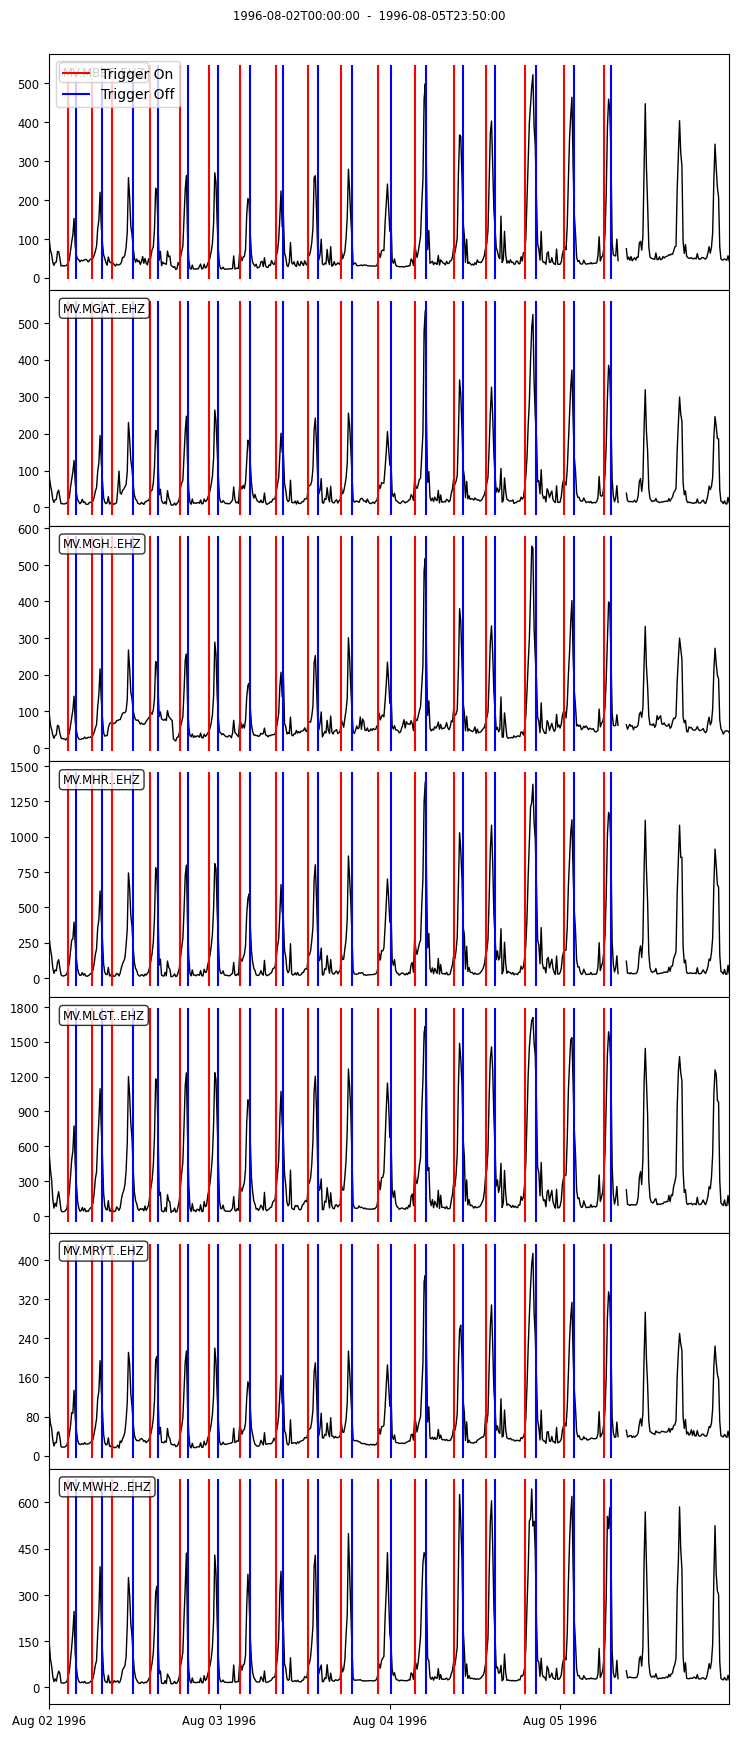

In [ ]:
from flovopy.processing.detection import run_coincidence_trigger_dataframe, filter_events_df, plot_stream_with_event_markers
df_events = run_coincidence_trigger_dataframe(
    st2,
    trigger_type="recstalta",
    sta_seconds=sta_minutes * 60,
    lta_seconds=lta_seconds,
    threshold_on=threshON,
    threshold_off=threshOFF,
    min_channels=4,
    pretrigger_seconds=10,
    posttrigger_seconds=15,
    write_mseed=False,
    outdir="events",
    make_plots=False,
    event_templates={},
)


df_filtered = filter_events_df(
    df_events,
    min_duration_s=lta_seconds / 2,
    max_duration_s=lta_seconds * 2,
)

display(df_filtered)

fig, axes = plot_stream_with_event_markers(st2, df_filtered)

This effectively recreates a banded tremor detector that I wrote back in year 2000 at the Montserrat Volcano Observatory, in MATLAB. However, I am not quite sure why this ObsPy-based version misses the last 3 bands in this plot! 